In [21]:
import os
from dotenv import load_dotenv
load_dotenv()

GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

# Load LLM, Embedding

In [ ]:
# llm and embedding
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)
embedding = GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")

# Split chunk, vectorstore

In [23]:
# Read pdf
from langchain_community.document_loaders import PyPDFLoader
loader=PyPDFLoader("D:\THTK\C2.1 Import file.pdf")
docs=loader.load()
docs

[Document(metadata={'producer': 'MiKTeX-dvipdfmx (20250410)', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-26T00:36:26+07:00', 'author': 'Nguyễn Thành Duy', 'source': 'D:\\THTK\\C2.1 Import file.pdf', 'total_pages': 6, 'page': 0, 'page_label': '1'}, page_content='Import File\nNguyễn Thành Duy\nNgày 26 tháng 3 năm 2026\nMục lục\n1 Nhập dữ liệu 1\n1.1 Nhập trực tiếp bằng hàm c() . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1\n1.2 Thiết lập Working Directory . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1\n2 Import dữ liệu 3\n2.1 Đọc file csv . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 3\n2.2 Đọc file txt . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 4\n2.3 Kiểm tra dữ liệu sau khi đọc . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 4\n2.4 Một số tuỳ chọn quan trọng khi đọc file . . . . . . . . . . . . . . . . . . . . . . 4\n2.5 Đọc các file dữ liệu khác . . . . . . . . . . . . . .

In [24]:
full_text="\n".join([doc.page_content for doc in docs])
full_text

'Import File\nNguyễn Thành Duy\nNgày 26 tháng 3 năm 2026\nMục lục\n1 Nhập dữ liệu 1\n1.1 Nhập trực tiếp bằng hàm c() . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1\n1.2 Thiết lập Working Directory . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1\n2 Import dữ liệu 3\n2.1 Đọc file csv . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 3\n2.2 Đọc file txt . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 4\n2.3 Kiểm tra dữ liệu sau khi đọc . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 4\n2.4 Một số tuỳ chọn quan trọng khi đọc file . . . . . . . . . . . . . . . . . . . . . . 4\n2.5 Đọc các file dữ liệu khác . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 5\n1 Nhập dữ liệu\nTa chỉ khảo sát dữ liệu một biến kiểu vector (hay mảng) và dữ liệu nhiều biến kiểu data.frame.\nĐối với các bộ dữ liệu nhỏ, ta dùng phương pháp nhập trực tiếp từ bàn phím thông qua hàm c()\nvà đối với bộ dữ liệu lớn, ta dùn

In [25]:
# Split docs
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

text_split=RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)
doc_split=text_split.split_documents(docs)
doc_split

[Document(metadata={'producer': 'MiKTeX-dvipdfmx (20250410)', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-26T00:36:26+07:00', 'author': 'Nguyễn Thành Duy', 'source': 'D:\\THTK\\C2.1 Import file.pdf', 'total_pages': 6, 'page': 0, 'page_label': '1'}, page_content='Import File\nNguyễn Thành Duy\nNgày 26 tháng 3 năm 2026\nMục lục\n1 Nhập dữ liệu 1\n1.1 Nhập trực tiếp bằng hàm c() . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1\n1.2 Thiết lập Working Directory . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1\n2 Import dữ liệu 3\n2.1 Đọc file csv . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 3\n2.2 Đọc file txt . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 4'),
 Document(metadata={'producer': 'MiKTeX-dvipdfmx (20250410)', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-26T00:36:26+07:00', 'author': 'Nguyễn Thành Duy', 'source': 'D:\\THTK\\C2.1 Import file.pdf', 'total_pages': 6, 'page':

In [26]:
# Vectorstore
vectorstore=FAISS.from_documents(docs,embedding)
retriever=vectorstore.as_retriever()

NameError: name 'embedding' is not defined

# Build Tools and Node

In [27]:
# Define GraphState
from pydantic import BaseModel,Field
from typing import List, Optional, Literal

class GraphState(BaseModel):
    question: str
    decision: Optional[Literal["ask_back", "split_tasks", "transform"]] = None
    sub_tasks: List[str]=[]
    context: List[str]=[]
    answer: str=""
    is_clear:bool = False

## Tools

In [28]:
from langchain_core.tools import Tool
from langchain_community.tools.tavily_search import TavilySearchResults

# Tool 1: Web Search
def web_search_safe(query: str):
    try:
        tool = TavilySearchResults(k=3)
        return tool.invoke({"query": query})
    except Exception as e:
        return f"Web Search Error: {str(e)}. Try refining your web query."

web_search_tool = Tool(
    name="tavily_web_search",
    description="Search the web for real-time information. Useful for external news, events, or facts not in datastore.",
    func=web_search_safe
)

# Tool 2: RAG retriever
def rag_search_safe(quey: str):
    try:
        docs=retriever.invoke(quey)
        return "\n".join([d.page_content for d in docs])
    except Exception as e:
        return f"RAG Error: {str(e)}."
rag_tool = Tool(
    name="internal_knowledge_search",
    description="Searches and returns internal company rules, policies, and business logic mapping.",
    func=rag_search_safe
)

tools=[rag_tool,web_search_tool]

## Node

In [29]:
from langchain_core.prompts import ChatPromptTemplate

In [30]:
# Grade Result
class GradeResult(BaseModel):
    """Schema for evaluating the user's question."""
    is_clear: bool = Field(description="Whether the question is clear or not") 
    decision: Literal["ask_back", "split_tasks", "transform"] = Field(description="Routing decision based on the question's content")
def grade_query(state: GraphState):
    """
    Evaluates the user's question to determine the next workflow step.
    """
    print("---NODE: GRADING QUERY---")
    grade_prompt = """
    You are a query router.

    Analyze the user question and decide:
    1. Whether the question is clear.
    2. What action to take next.

    Routing rules:
    - ask_back: unclear, vague, or missing intent
    - split_tasks: multiple steps or compound request
    - transform: clear but needs rewriting for retrieval/search

    Return your answer strictly following the provided schema.
    """
    structured_llm = llm.with_structured_output(GradeResult)

    prompt = ChatPromptTemplate.from_messages([
        ("system", grade_prompt),
        ("human", "User question: {question}")
    ])

    chain = prompt | structured_llm
    result: GradeResult = chain.invoke({
        "question": state.question
    })

    return {
        "is_clear": result.is_clear,
        "decision": result.decision
    }

In [31]:
# sub tasks
class TaskList(BaseModel):
    """A list of sequential steps to fulfill a user request."""
    tasks: List[str] = Field(description="A list of clear, executable steps in logical order")
    
def sub_task_node(state: GraphState):
    """
    Decomposes a complex user request into smaller, sequential sub-tasks.
    """
    print("---NODE: SUB-TASK PLANNING---")
    planner_prompt = """You are an expert Strategic Planner. 
    Your goal is to break down a complex 'User Question' into a list of smaller, logical, and executable sub-tasks.
    
    Rules:
    - Breakdown: Each task must be a single, independent action.
    - Sequence: Arrange tasks in a logical chronological order."""

    prompt = ChatPromptTemplate.from_messages([
        ("system", planner_prompt),
        ("human", "User Question: {question}")
    ])
    planner_chain = prompt | llm.with_structured_output(TaskList)

    result = planner_chain.invoke({
        "question": state.question,
    })

    return {
        "sub_tasks": result.tasks
    }

In [32]:
from langchain_core.messages import HumanMessage, SystemMessage

def execute_task_node(state: GraphState):
    """
    Executes the first sub-task by manually routing tool calls from the LLM.
    """
    # Get the current task from the queue
    current_task = state.sub_tasks[0]
    print(f"\n---NODE: EXECUTING TASK: {current_task}---")
    
    # Bind tools to the LLM
    llm_with_tools = llm.bind_tools(tools)
    
    # Prepare the context for the LLM
    existing_context = "\n".join(state.context) if state.context else "No prior context."
    
    # Invoke the LLM to decide on tool usage
    response = llm_with_tools.invoke([
        SystemMessage(content="You are a helpful assistant. Solve the current task using tools if necessary."),
        HumanMessage(content=f"Context:\n{existing_context}\n\nCurrent Task: {current_task}")
    ])
    
    step_output = ""
    
    # 1. Check if the LLM requested any tools
    if response.tool_calls:
        for tool_call in response.tool_calls:
            t_name = tool_call["name"]
            t_args = tool_call["args"]

            if t_name == "internal_knowledge_search":
                # Using .get() is safer to avoid KeyErrors
                query_val = t_args.get('quey') or t_args.get('query')
                print(f"-> Running RAG with keyword: {query_val}")
                result = rag_tool.func(quey=query_val) 
                step_output += f"\n[RAG Result]: {result}"

            elif t_name == "tavily_web_search":
                query_val = t_args.get('query') or t_args.get('quey')
                print(f"-> Running Web Search with keyword: {query_val}")
                # Note: Corrected the extra parenthesis and ensured 'query' key is used
                result = web_search_tool.func(query=query_val)
                step_output += f"\n[Web Result]: {result}"
    else:
        # If no tool is needed, take the direct text response
        step_output = response.content

    # 2. Package the result for this specific task
    final_context_entry = f"Task: {current_task}\nResult: {step_output}"
    
    # 3. Update State: Append to context and "pop" the first task from the list
    return {
        "context": state.context + [final_context_entry],
        "sub_tasks": state.sub_tasks[1:]
    }

def finalize_answer_node(state: GraphState):
    """
    Synthesizes all gathered research into a final response.
    """
    print("---NODE: GENERATING FINAL ANSWER---")
    full_history = "\n\n".join(state.context)
    
    prompt = f"""Based on the following research history, provide a comprehensive final answer to: {state.question}
    
    Research History:
    {full_history}"""
    
    response = llm.invoke(prompt)
    
    return {"answer": response.content}

# Conditional Logic for the Graph Loop
def should_continue(state: GraphState):
    """
    Routes the workflow back to execution if tasks remain, otherwise to finalization.
    """
    if len(state.sub_tasks) > 0:
        return "continue_working" 
    else:
        return "finish_all"

In [ ]:
from langgraph.graph import StateGraph, END
workflow = StateGraph(GraphState)
workflow.add_node("grade_query", grade_query)
workflow.add_node("sub_task_planning", sub_task_node)
workflow.add_node("execute_task", execute_task_node)
workflow.add_node("finalize_answer", finalize_answer_node)

workflow.set_entry_point("grade_query")
def route_after_grading(state: GraphState):
    if state.decision == "split_tasks":
        return "split"
    elif state.decision == "ask_back":
        return "ask_back"
    else:
        return "process_directly"

workflow.add_conditional_edges(
    "grade_query",
    route_after_grading,
    {
        "split": "sub_task_planning",
        "ask_back": END, 
        "process_directly": "execute_task" 
    }
)

workflow.add_edge("sub_task_planning", "execute_task")
workflow.add_conditional_edges(
    "execute_task",
    should_continue, 
    {
        "continue_working": "execute_task",
        "finish_all": "finalize_answer"     
    }
)

workflow.add_edge("finalize_answer", END)

app = workflow.compile()

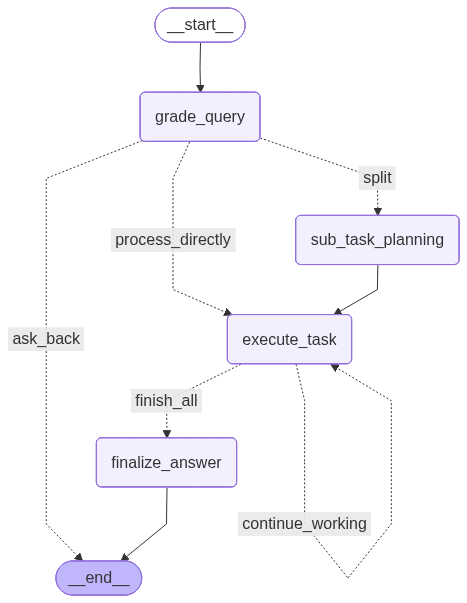

In [34]:
app